# WESM Price Prediction - Model 2: Polynomial Ridge Regression

## Setup and Loading

This notebook implements Polynomial Ridge Regression as the second model for predicting Luzon GWAP from WESM market features.

### Why this model?

Model 1 (Linear Regression) performed well in the normal price range but failed badly at the extremes. The RMSE for negative GWAP intervals was ₱2,209 and for intervals above ₱10,000/MWh it reached ₱6,264. Our analysis showed these were not random errors but consistent failures where the model simply could not keep up with sudden price spikes (both positive and negative). So in this case, the likely cause is underfitting because a straight line cannot really capture what happens at market extremes.

**Polynomial features** are the next step because they give the model more flexibility. Instead of only learning from each feature individually, the model can now use squared terms (like `GWAP_Lag_1²`) and interaction terms (like `energy_demand_mw × outage_count`) to capture more complex patterns. For example, the model can learn that the effect of high demand is much worse when there are also a lot of outages, which is something a purely linear model cannot express.

**Ridge regularization** is needed alongside this because expanding 16 features to degree 2 produces 152 features in total. With that many features, the model can easily overfit the training data if left unconstrained. Ridge keeps the coefficients in check without throwing out any of the polynomial terms. The strength of that constraint is controlled by `alpha`, which is tuned on the validation set.

In [81]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

plt.style.use('seaborn-v0_8-darkgrid')
pd.set_option('display.max_columns', None)

df = pd.read_csv("final_dataset.csv")
df["datetime"] = pd.to_datetime(df["datetime"])

print(f"Dataset Shape: {df.shape}")
print(f"Date Range: {df['datetime'].min()} to {df['datetime'].max()}")
print(df.head())

Dataset Shape: (34535, 19)
Date Range: 2025-10-29 00:05:00 to 2026-02-26 00:00:00
             datetime       GWAP  energy_demand_mw  energy_supply_mw  \
0 2025-10-29 00:05:00  2258.5866           9504.45           9705.25   
1 2025-10-29 00:10:00  2913.4257           9483.49           9648.89   
2 2025-10-29 00:15:00  2883.5764           9434.35           9627.98   
3 2025-10-29 00:20:00  2888.6233           9417.62           9614.19   
4 2025-10-29 00:25:00  2887.9553           9379.48           9575.17   

   energy_shortage_mw  reserve_demand_mw  reserve_supply_mw  outage_count  \
0             -200.80             1428.0             1428.0           4.0   
1             -165.40             1428.0             1428.0           4.0   
2             -193.63             1428.0             1428.0           4.0   
3             -196.57             1428.0             1428.0           4.0   
4             -195.69             1428.0             1428.0           4.0   

   GWAP_Lag_1  GWAP_La

---

## I. Feature Selection

The same 16 base features as Model 1 are used, for the same reasons. Refer to Notebook 3 for the full feature justification table.

**Note:** `energy_shortage_mw` remains excluded for the same perfect multicollinearity reason. The polynomial expansion will generate squared terms and pairwise interaction terms from these 16 features, which is exactly why Ridge regularization is necessary here.

In [82]:
FEATURE_COLS = [
    "energy_demand_mw",
    "energy_supply_mw",
    "reserve_demand_mw",
    "reserve_supply_mw",
    "outage_count",
    "GWAP_Lag_1",
    "GWAP_Lag_12",
    "GWAP_Lag_288",
    "hour_sin",
    "hour_cos",
    "dow_1", "dow_2", "dow_3", "dow_4", "dow_5", "dow_6"
]

TARGET_COL = "GWAP"

print(f"Number of base features: {len(FEATURE_COLS)}")
print(f"Features: {FEATURE_COLS}")

Number of base features: 16
Features: ['energy_demand_mw', 'energy_supply_mw', 'reserve_demand_mw', 'reserve_supply_mw', 'outage_count', 'GWAP_Lag_1', 'GWAP_Lag_12', 'GWAP_Lag_288', 'hour_sin', 'hour_cos', 'dow_1', 'dow_2', 'dow_3', 'dow_4', 'dow_5', 'dow_6']


---

## II. Train / Validation / Test Split

The same chronological 70/10/20 split as Model 1 is used. Unlike Model 1, the validation set actually does something more important here as it is used to select the best `alpha` before the final model is retrained on train+val.

Chronological splitting is especially important here because the polynomial features include lag interactions (e.g., `GWAP_Lag_1 × GWAP_Lag_12`). A random split would allow future-to-past information leakage through these interaction terms.

In [83]:
df_sorted = df.sort_values("datetime").reset_index(drop=True)

n = len(df_sorted)
train_end = int(n * 0.70)
val_end   = int(n * 0.80)

train_df = df_sorted.iloc[:train_end]
val_df   = df_sorted.iloc[train_end:val_end]
test_df  = df_sorted.iloc[val_end:]

print(f"Train : {len(train_df):>6} rows | {train_df['datetime'].min().date()} to {train_df['datetime'].max().date()}")
print(f"Val   : {len(val_df):>6} rows | {val_df['datetime'].min().date()} to {val_df['datetime'].max().date()}")
print(f"Test  : {len(test_df):>6} rows | {test_df['datetime'].min().date()} to {test_df['datetime'].max().date()}")

Train :  24174 rows | 2025-10-29 to 2026-01-20
Val   :   3454 rows | 2026-01-20 to 2026-02-01
Test  :   6907 rows | 2026-02-01 to 2026-02-26


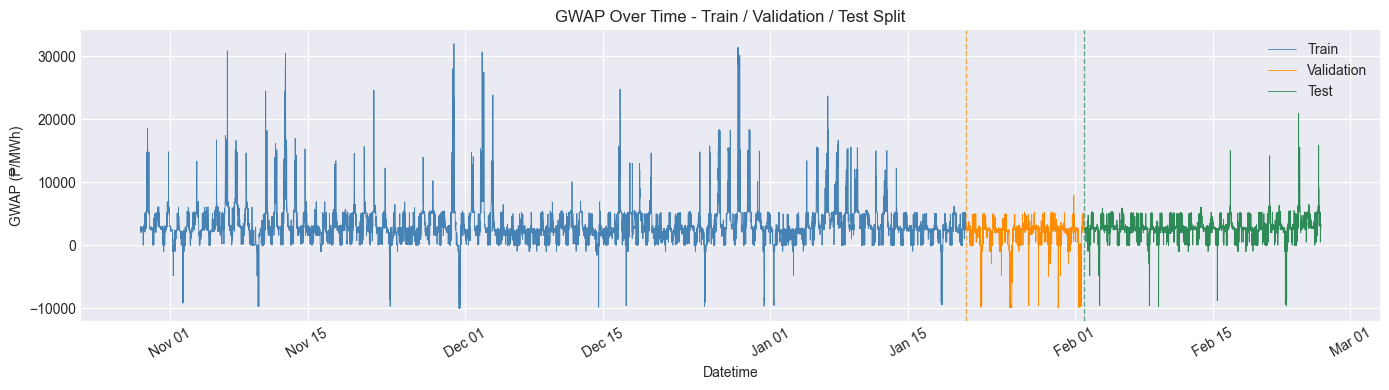

In [84]:
fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(train_df["datetime"], train_df["GWAP"], color="steelblue",  label="Train",      linewidth=0.6)
ax.plot(val_df["datetime"],   val_df["GWAP"],   color="darkorange", label="Validation", linewidth=0.6)
ax.plot(test_df["datetime"],  test_df["GWAP"],  color="seagreen",   label="Test",       linewidth=0.6)

ax.axvline(train_df["datetime"].max(), color="darkorange", linestyle="--", linewidth=1, alpha=0.7)
ax.axvline(val_df["datetime"].max(),   color="seagreen",   linestyle="--", linewidth=1, alpha=0.7)

ax.set_title("GWAP Over Time - Train / Validation / Test Split")
ax.set_xlabel("Datetime")
ax.set_ylabel("GWAP (₱/MWh)")
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [85]:
X_train = train_df[FEATURE_COLS]
y_train = train_df[TARGET_COL]

X_val   = val_df[FEATURE_COLS]
y_val   = val_df[TARGET_COL]

X_test  = test_df[FEATURE_COLS]
y_test  = test_df[TARGET_COL]

---

## III. Feature Scaling

Same standardization approach as Model 1, with one important difference: **scaling is applied before polynomial expansion**, not after. If we expand first, the squared terms (e.g., `GWAP_Lag_1²`) would reach into the billions on the raw scale, making the coefficients incomparable and the Ridge penalty ineffective. Scaling first ensures all polynomial terms are derived from standardized inputs.

The scaler is **fit only on the training set** and applied to validation and test to avoid data leakage.

In [86]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

print(f"Train mean (before poly): {X_train_scaled.mean(axis=0).mean():.6f}")
print(f"Train std  (before poly): {X_train_scaled.std(axis=0).mean():.6f}")

Train mean (before poly): -0.000000
Train std  (before poly): 1.000000


---

## IV. Polynomial Feature Expansion

`PolynomialFeatures` from scikit-learn generates all polynomial and interaction terms for us. For degree 2 with 16 features, this produces 16 original features, 16 squared terms (e.g., `GWAP_Lag_1²`), and 120 pairwise interaction terms (e.g., `GWAP_Lag_1 × energy_demand_mw`). We end up with a **total of 152 features** (with `include_bias=False` since Ridge already does that with `fit_intercept=True`).

We only go up to degree 2 for two reasons. First, degree 3 would produce over 900 features and that would most likely make our model overfit. Second, degree 2 already covers the most economically meaningful non-linear patterns: whether a feature amplifies its own effect at extreme values (squared terms) and whether two features interact with each other (cross terms). Going higher adds too much complexity without a clear economic justification.

The `PolynomialFeatures` transformer is **fit on training data only**. Validation and test are then transformed using the same structure.

In [87]:
poly = PolynomialFeatures(degree=2, include_bias=False)

X_train_poly = poly.fit_transform(X_train_scaled)
X_val_poly   = poly.transform(X_val_scaled)
X_test_poly  = poly.transform(X_test_scaled)

feature_names = poly.get_feature_names_out(FEATURE_COLS)

print(f"Original features  : {X_train_scaled.shape[1]}")
print(f"Polynomial features: {X_train_poly.shape[1]}")
print(f"\nSample of generated feature names:")
print(feature_names[:10].tolist())
print("...")
print(feature_names[-5:].tolist())

Original features  : 16
Polynomial features: 152

Sample of generated feature names:
['energy_demand_mw', 'energy_supply_mw', 'reserve_demand_mw', 'reserve_supply_mw', 'outage_count', 'GWAP_Lag_1', 'GWAP_Lag_12', 'GWAP_Lag_288', 'hour_sin', 'hour_cos']
...
['dow_4 dow_5', 'dow_4 dow_6', 'dow_5^2', 'dow_5 dow_6', 'dow_6^2']


---

## V. Hyperparameter Tuning

Ridge has one hyperparameter: `alpha`, which controls the strength of the L2 regularization. Higher alpha means stronger shrinkage toward zero; too high and the model collapses back toward linear by ignoring most polynomial terms.

Following the coarse-to-fine search from the Tips and Tricks lecture, we search in two passes. The coarse search sweeps a wide range (0.01 to 1,000,000 on a log scale) with large gaps between values, just to find the general neighborhood of the best alpha. Then the fine search zooms into a narrow window around that neighborhood and searches more densely to pin down the exact best value. This is more efficient than trying to search the full range at high resolution from the start.

In [88]:
alphas_coarse = np.logspace(-2, 6, 50)
val_rmses_coarse = []

for alpha in alphas_coarse:
    model = Ridge(alpha=alpha)
    model.fit(X_train_poly, y_train)
    y_val_pred = model.predict(X_val_poly)
    val_rmses_coarse.append(np.sqrt(mean_squared_error(y_val, y_val_pred)))

best_idx_coarse = np.argmin(val_rmses_coarse)
best_alpha_coarse = alphas_coarse[best_idx_coarse]
print(f"Coarse best alpha : {best_alpha_coarse:.4f}  (val RMSE: {val_rmses_coarse[best_idx_coarse]:.4f})")

Coarse best alpha : 120.6793  (val RMSE: 1090.9687)


In [89]:
alphas_fine = np.logspace(
    np.log10(best_alpha_coarse) - 1,
    np.log10(best_alpha_coarse) + 1,
    100
)
val_rmses_fine = []

for alpha in alphas_fine:
    model = Ridge(alpha=alpha)
    model.fit(X_train_poly, y_train)
    y_val_pred = model.predict(X_val_poly)
    val_rmses_fine.append(np.sqrt(mean_squared_error(y_val, y_val_pred)))

best_idx_fine = np.argmin(val_rmses_fine)
best_alpha = alphas_fine[best_idx_fine]
print(f"Fine best alpha   : {best_alpha:.4f}  (val RMSE: {val_rmses_fine[best_idx_fine]:.4f})")

Fine best alpha   : 123.5190  (val RMSE: 1090.9667)


The plot below shows validation RMSE across the fine alpha search. There is a clear minimum at alpha ≈ 123.5, confirming that regularization is really needed when working with 152 polynomial features. Without it, the model would overfit the expanded feature space.

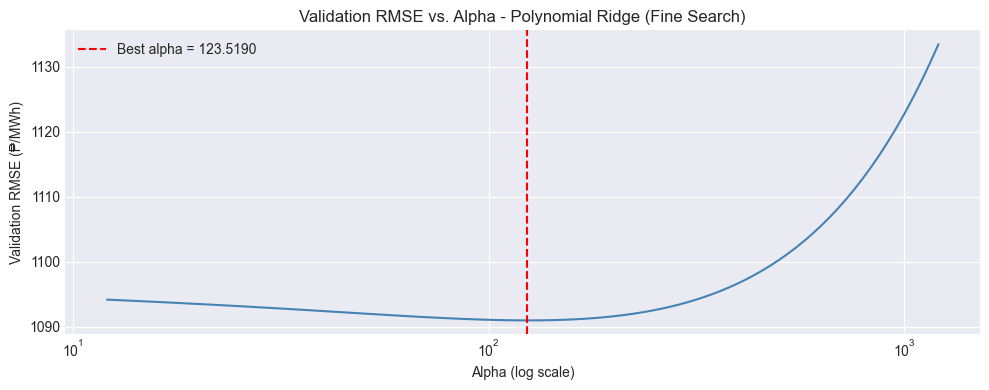

In [90]:
fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(alphas_fine, val_rmses_fine, color="steelblue", linewidth=1.5)
ax.axvline(best_alpha, color="red", linestyle="--", linewidth=1.5, label=f"Best alpha = {best_alpha:.4f}")
ax.set_xscale("log")
ax.set_title("Validation RMSE vs. Alpha - Polynomial Ridge (Fine Search)")
ax.set_xlabel("Alpha (log scale)")
ax.set_ylabel("Validation RMSE (₱/MWh)")
ax.legend()
plt.tight_layout()
plt.show()

---

## VI. Model Training

Same two-model protocol as Model 1:

1. **`ridge_poly`** - trained on the training set only using the best alpha. Used to evaluate train and validation performance.
2. **`ridge_poly_final`** - retrained on the combined train + validation set using the same best alpha. This is the model used for final test evaluation.

In [91]:
# Selection-phase model (train only)
ridge_poly = Ridge(alpha=best_alpha)
ridge_poly.fit(X_train_poly, y_train)

# Final model (train + val combined)
X_trainval_scaled = np.vstack([X_train_scaled, X_val_scaled])
y_trainval        = pd.concat([y_train, y_val])
X_trainval_poly   = poly.transform(X_trainval_scaled)

ridge_poly_final = Ridge(alpha=best_alpha)
ridge_poly_final.fit(X_trainval_poly, y_trainval)

print(f"Best alpha              : {best_alpha:.4f}")
print(f"ridge_poly       intercept (train only)  : {ridge_poly.intercept_:.4f}")
print(f"ridge_poly_final intercept (train + val) : {ridge_poly_final.intercept_:.4f}")

Best alpha              : 123.5190
ridge_poly       intercept (train only)  : 3202.6905
ridge_poly_final intercept (train + val) : 3236.7240


---

## VII. Evaluation

Same evaluation protocol as Model 1. Train and validation are evaluated using `ridge_poly`. Train+Val and Test are evaluated using `ridge_poly_final`.

In [92]:
def evaluate(model, X, y, label):
    y_pred = model.predict(X)
    rmse = np.sqrt(mean_squared_error(y, y_pred))
    mae  = mean_absolute_error(y, y_pred)
    r2   = r2_score(y, y_pred)
    print(f"{label:<12} | RMSE: {rmse:>10.4f} | MAE: {mae:>10.4f} | R\u00b2: {r2:>8.4f}")
    return y_pred, rmse, mae, r2

print(f"{'Split':<12} | {'RMSE':>14} | {'MAE':>14} | {'R\u00b2':>12}")
print("-" * 58)
y_train_pred,    train_rmse,    train_mae,    train_r2    = evaluate(ridge_poly,       X_train_poly,    y_train,    "Train")
y_val_pred,      val_rmse,      val_mae,      val_r2      = evaluate(ridge_poly,       X_val_poly,      y_val,      "Validation")
y_trainval_pred, trainval_rmse, _,            _           = evaluate(ridge_poly_final, X_trainval_poly, y_trainval, "Train+Val")
y_test_pred,     test_rmse,     test_mae,     test_r2     = evaluate(ridge_poly_final, X_test_poly,     y_test,     "Test")

Split        |           RMSE |            MAE |           R²
----------------------------------------------------------
Train        | RMSE:  1175.4184 | MAE:   578.5219 | R²:   0.8248
Validation   | RMSE:  1090.9667 | MAE:   567.1597 | R²:   0.8242
Train+Val    | RMSE:  1160.3747 | MAE:   566.1041 | R²:   0.8319
Test         | RMSE:   968.2435 | MAE:   544.9307 | R²:   0.6472


### Bias-Variance Diagnosis

Same framework as Model 1. `ridge_poly` is compared against its train RMSE for the val gap and `ridge_poly_final` is compared against its train+val RMSE for the test gap.

The val-train gap is -84.5 (-7.2%) and the test-train+val gap is -192.1 (-16.6%). Both are negative, meaning the model is not overfitting and the regularization is working as intended. However, the absolute performance is worse than the linear baseline, which points to a different problem: the polynomial terms are adding noise rather than predictive value for this dataset.

In [93]:
gap_val  = val_rmse - train_rmse
gap_test = test_rmse - trainval_rmse

print(f"Val  - Train gap     : {gap_val:.4f}  ({gap_val / train_rmse * 100:.1f}% of train RMSE)")
print(f"Test - Train+Val gap : {gap_test:.4f}  ({gap_test / trainval_rmse * 100:.1f}% of train+val RMSE)")

Val  - Train gap     : -84.4517  (-7.2% of train RMSE)
Test - Train+Val gap : -192.1312  (-16.6% of train+val RMSE)


### Comparison with Model 1 (Linear Regression)

The more important question is whether polynomial features improve over the linear baseline. The table below compares test performance directly.

In [94]:
lr_test_rmse = 934.4698
lr_test_mae  = 459.4758
lr_test_r2   = 0.6714

comparison = pd.DataFrame({
    "Model"    : ["Linear Regression (baseline)", "Polynomial Ridge (degree=2)"],
    "Test RMSE": [lr_test_rmse, test_rmse],
    "Test MAE" : [lr_test_mae,  test_mae],
    "Test R²"  : [lr_test_r2,   test_r2]
})

print(comparison.to_string(index=False))
print()
print(f"RMSE improvement over baseline : {lr_test_rmse - test_rmse:.4f} ₱/MWh  ({(lr_test_rmse - test_rmse) / lr_test_rmse * 100:.2f}%)")

                       Model  Test RMSE   Test MAE  Test R²
Linear Regression (baseline)  934.46980 459.475800 0.671400
 Polynomial Ridge (degree=2)  968.24348 544.930665 0.647246

RMSE improvement over baseline : -33.7737 ₱/MWh  (-3.61%)


Polynomial Ridge performs worse than the Linear Regression baseline on all three metrics: test RMSE increased from ₱934 to ₱968 (+3.6%), MAE increased from ₱459 to ₱545, and R² dropped from 0.671 to 0.647. This is a meaningful regression in performance, not just floating point noise.

This is a counterintuitive result given that polynomial features were motivated by underfitting. The explanation lies in what the polynomial expansion actually produces: of the 152 features, many interaction terms (e.g., `dow_1 × dow_2`, `hour_sin × hour_cos`) have no economic meaning and introduce noise that Ridge cannot fully suppress even at alpha ≈ 123.5.

---

## VIII. Visualizations

### Actual vs. Predicted (Time Series)

Same two-panel layout as Model 1. Since Polynomial Ridge performs worse overall, the predictions in the test period track the actual values less closely, particularly in the moderate price range where Model 1 was already performing well.

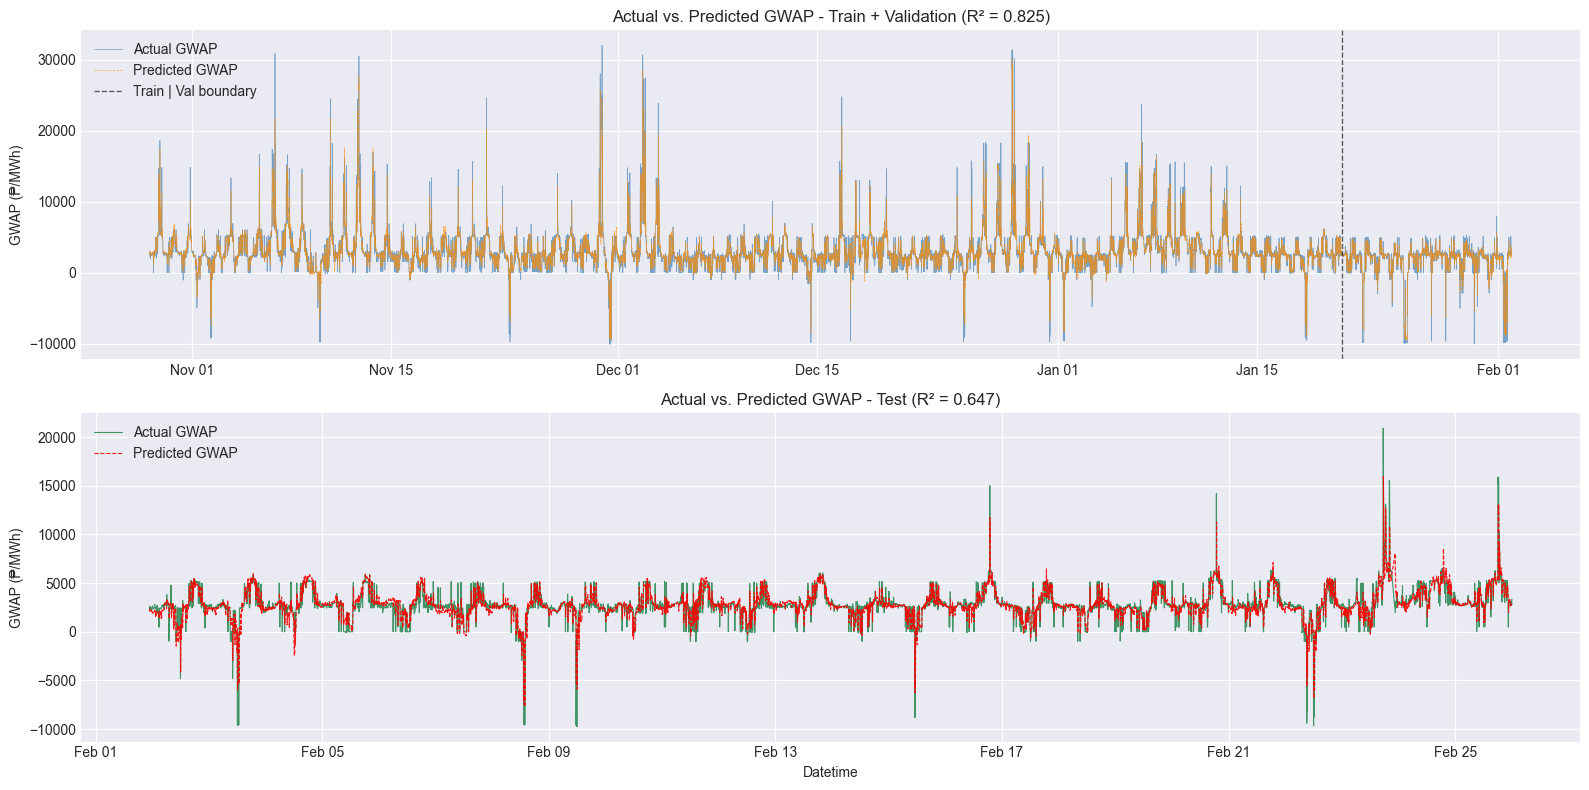

Train+Val GWAP std : 2830.47
Test GWAP std      : 1630.35


In [95]:
fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=False)

# Train+Val
axes[0].plot(train_df["datetime"].values, y_train.values, color="steelblue", linewidth=0.5, alpha=0.7, label="Actual GWAP")
axes[0].plot(val_df["datetime"].values,   y_val.values,   color="steelblue", linewidth=0.5, alpha=0.7)
axes[0].plot(train_df["datetime"].values, ridge_poly_final.predict(X_train_poly), color="darkorange", linewidth=0.5, alpha=0.7, linestyle="--", label="Predicted GWAP")
axes[0].plot(val_df["datetime"].values,   ridge_poly_final.predict(X_val_poly),   color="darkorange", linewidth=0.5, alpha=0.7, linestyle="--")
axes[0].axvline(val_df["datetime"].min(), color="black", linestyle="--", linewidth=1, alpha=0.6, label="Train | Val boundary")
axes[0].set_title(f"Actual vs. Predicted GWAP - Train + Validation (R² = {round(train_r2, 3)})")
axes[0].set_ylabel("GWAP (₱/MWh)")
axes[0].legend(loc="upper left")
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))

# Test
axes[1].plot(test_df["datetime"].values, y_test.values, color="seagreen", linewidth=0.8, alpha=0.9, label="Actual GWAP")
axes[1].plot(test_df["datetime"].values, y_test_pred,   color="red",      linewidth=0.8, alpha=0.9, linestyle="--", label="Predicted GWAP")
axes[1].set_title(f"Actual vs. Predicted GWAP - Test (R² = {round(test_r2, 3)})")
axes[1].set_ylabel("GWAP (₱/MWh)")
axes[1].set_xlabel("Datetime")
axes[1].legend(loc="upper left")
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))

plt.tight_layout()
plt.show()

print(f"Train+Val GWAP std : {y_trainval.std():.2f}")
print(f"Test GWAP std      : {y_test.std():.2f}")

### Actual vs. Predicted - Scatter Plot

Same as Model 1. Since performance is worse overall, the extreme points are not really closer to the diagonal.

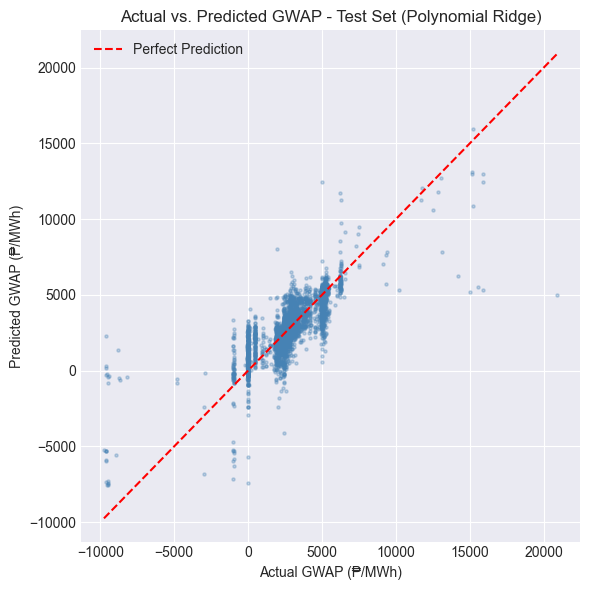

In [96]:
fig, ax = plt.subplots(figsize=(6, 6))

ax.scatter(y_test, y_test_pred, alpha=0.3, s=5, color="steelblue")

lims = [min(y_test.min(), y_test_pred.min()), max(y_test.max(), y_test_pred.max())]
ax.plot(lims, lims, "r--", linewidth=1.5, label="Perfect Prediction")

ax.set_title("Actual vs. Predicted GWAP - Test Set (Polynomial Ridge)")
ax.set_xlabel("Actual GWAP (₱/MWh)")
ax.set_ylabel("Predicted GWAP (₱/MWh)")
ax.legend()
plt.tight_layout()
plt.show()

### Residual Plot

Residuals here are just the difference between actual and predicted GWAP (actual - predicted).

Given that Polynomial Ridge underperforms the linear baseline, we expect the spread to be wider than Model 1, particularly in the normal price range where the additional polynomial noise is hurting rather than helping.

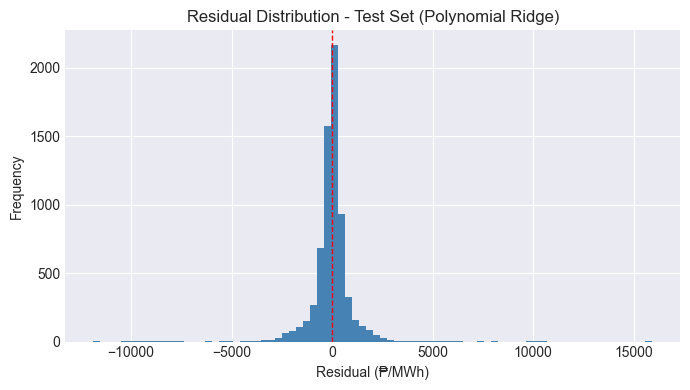

Mean Residual : -29.1939  (close to 0 = unbiased)
Std Residual  : 967.8033
Max Residual  : 15906.7644
Min Residual  : -11873.9051


In [97]:
residuals_test = y_test.values - y_test_pred

fig, ax = plt.subplots(figsize=(7, 4))

ax.hist(residuals_test, bins=80, color="steelblue", edgecolor="none")
ax.axvline(0, color="red", linestyle="--", linewidth=1)
ax.set_title("Residual Distribution - Test Set (Polynomial Ridge)")
ax.set_xlabel("Residual (₱/MWh)")
ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

print(f"Mean Residual : {residuals_test.mean():.4f}  (close to 0 = unbiased)")
print(f"Std Residual  : {residuals_test.std():.4f}")
print(f"Max Residual  : {residuals_test.max():.4f}")
print(f"Min Residual  : {residuals_test.min():.4f}")

The residual distribution shows the model is not systematically biased (mean near zero) but the spread is wider than Model 1, meaning individual predictions are less accurate on average. The polynomial terms are adding variance without reducing the systematic spike-related failures. The same extreme price events that defeated the linear model are still not captured here.

---

## IX. Feature Coefficients

With 152 features, we focus on the **top 20 by absolute magnitude** from `ridge_poly_final`. Features with no `^2` or space in the name are original features also present in Model 1; the rest are polynomial or interaction terms. Their presence in the top 20 confirms the model is actually using the expanded feature space.

In [98]:
coef_df = pd.DataFrame({
    "Feature"    : feature_names,
    "Coefficient": ridge_poly_final.coef_
}).sort_values("Coefficient", key=abs, ascending=False)

top20 = coef_df.head(20)
print("Top 20 features by absolute coefficient:")
print(top20.to_string(index=False))

n_original = sum(1 for f in top20["Feature"] if " " not in f and "^" not in f)
n_poly     = len(top20) - n_original
print(f"\nOriginal features in top 20 : {n_original}")
print(f"Polynomial/interaction terms : {n_poly}")

Top 20 features by absolute coefficient:
                      Feature  Coefficient
                   GWAP_Lag_1  1859.511492
                  GWAP_Lag_12   404.156795
                 GWAP_Lag_288   327.299485
          GWAP_Lag_1 hour_cos  -323.752769
             energy_demand_mw   277.153607
          GWAP_Lag_1 hour_sin  -232.535565
energy_demand_mw GWAP_Lag_288   219.562255
           energy_demand_mw^2   206.505056
energy_supply_mw GWAP_Lag_288  -186.562312
         GWAP_Lag_12 hour_sin   168.046584
           energy_supply_mw^2  -150.569876
         GWAP_Lag_12 hour_cos   145.910814
             energy_supply_mw  -144.912777
  energy_demand_mw GWAP_Lag_1  -132.694847
            hour_sin hour_cos   113.244169
 energy_demand_mw GWAP_Lag_12   110.263617
reserve_supply_mw GWAP_Lag_12   -97.625352
       energy_supply_mw dow_5    90.646863
       energy_demand_mw dow_5   -87.566439
reserve_demand_mw GWAP_Lag_12    86.015490

Original features in top 20 : 5
Polynomial/interaction 

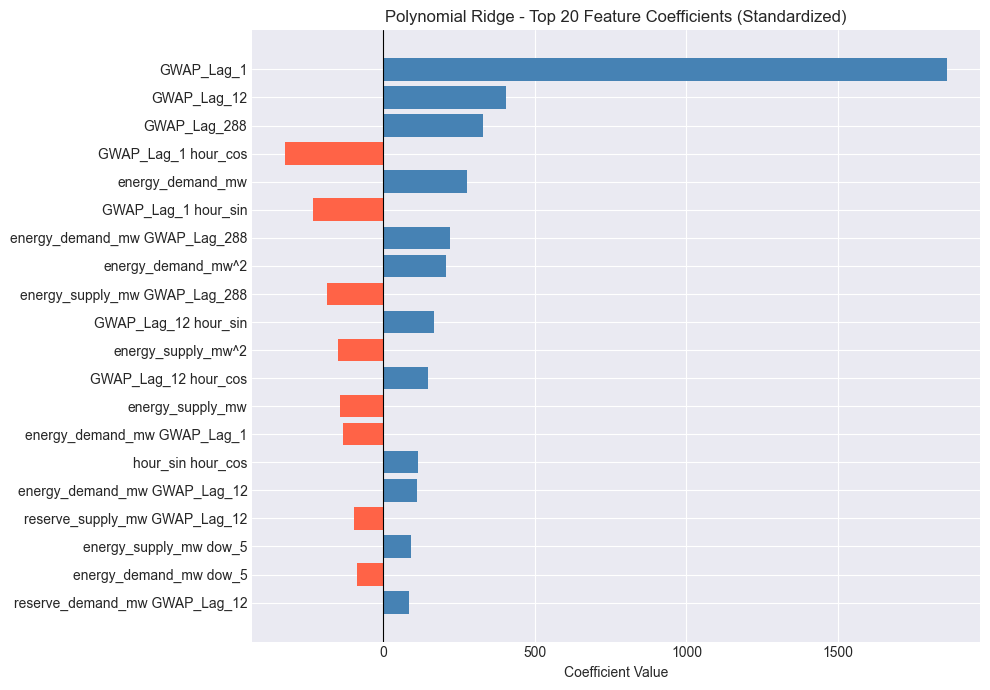

In [99]:
fig, ax = plt.subplots(figsize=(10, 7))

colors = ["steelblue" if c >= 0 else "tomato" for c in top20["Coefficient"]]
ax.barh(top20["Feature"], top20["Coefficient"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Polynomial Ridge - Top 20 Feature Coefficients (Standardized)")
ax.set_xlabel("Coefficient Value")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

The three lag features (GWAP_Lag_1, GWAP_Lag_12, GWAP_Lag_288) remain dominant, consistent with Model 1. The polynomial terms that appear in the top 20 are primarily lag-hour interactions (e.g., `GWAP_Lag_1 hour_cos`, `GWAP_Lag_1 hour_sin`), which have a plausible economic interpretation: the relationship between recent price and current price varies by time of day. Ridge has correctly identified these as the most useful polynomial terms and shrunk the rest.

Despite this, the overall model performance is worse. The useful interactions are not strong enough to compensate for the noise introduced by the many economically meaningless terms that Ridge cannot shrink to exactly zero.

---

## X. Error Analysis

### Where Does the Model Fail?

Same segmentation as Model 1. The key question is whether polynomial features reduce errors at the extremes (Negative GWAP and >₱10,000) where Model 1 struggled most.

In [100]:
error_df = test_df[["datetime", "GWAP"]].copy()
error_df["predicted"] = y_test_pred
error_df["residual"]  = error_df["GWAP"] - error_df["predicted"]
error_df["abs_error"] = error_df["residual"].abs()

bins   = [-10000, 0, 2000, 5000, 10000, 35000]
labels = ["Negative", "0-2k", "2k-5k", "5k-10k", ">10k"]
error_df["gwap_segment"] = pd.cut(error_df["GWAP"], bins=bins, labels=labels)

segment_summary = error_df.groupby("gwap_segment", observed=True).agg(
    count     = ("GWAP", "count"),
    mean_gwap = ("GWAP", "mean"),
    rmse      = ("residual", lambda x: np.sqrt((x**2).mean())),
    mae       = ("abs_error", "mean")
).reset_index()

lr_segment_rmses = [2208.886686, 1220.638104, 562.212687, 1014.637240, 6264.010822]
segment_summary["LR RMSE"]        = lr_segment_rmses
segment_summary["RMSE improvement"] = segment_summary["LR RMSE"] - segment_summary["rmse"]

print(segment_summary.to_string(index=False))

gwap_segment  count    mean_gwap        rmse         mae     LR RMSE  RMSE improvement
    Negative    459  -695.253988 2220.287698 1431.129122 2208.886686        -11.401012
        0-2k    411  1084.738367 1261.910164  973.180897 1220.638104        -41.272060
       2k-5k   5219  2806.565112  631.828686  408.756442  562.212687        -69.615999
      5k-10k    800  5302.908570  963.586391  611.853788 1014.637240         51.050849
        >10k     18 14405.645722 6376.226060 4677.088244 6264.010822       -112.215238


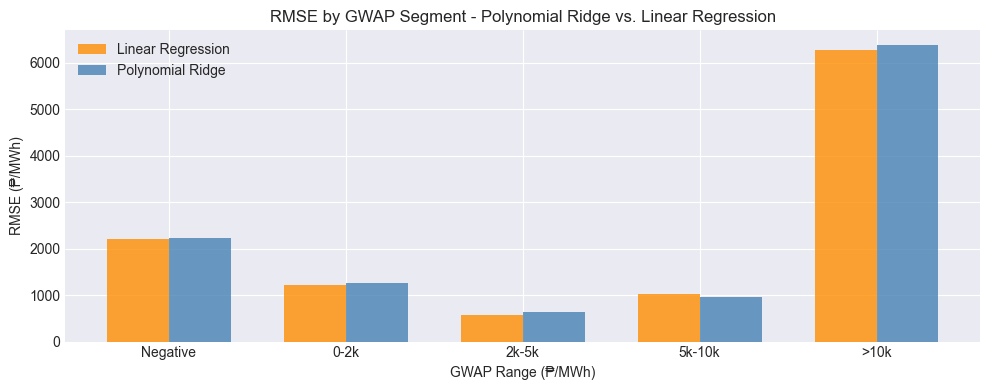

In [101]:
fig, ax = plt.subplots(figsize=(10, 4))

x = np.arange(len(segment_summary))
width = 0.35

ax.bar(x - width/2, segment_summary["LR RMSE"], width, label="Linear Regression", color="darkorange", alpha=0.8)
ax.bar(x + width/2, segment_summary["rmse"],    width, label="Polynomial Ridge",  color="steelblue",  alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels(segment_summary["gwap_segment"].astype(str))
ax.set_title("RMSE by GWAP Segment - Polynomial Ridge vs. Linear Regression")
ax.set_xlabel("GWAP Range (₱/MWh)")
ax.set_ylabel("RMSE (₱/MWh)")
ax.legend()
plt.tight_layout()
plt.show()

Polynomial Ridge actually improves on the ₱5,000-₱10,000 range (RMSE drops from ₱1,015 to ₱964, a gain of ₱51), suggesting that some lag-hour interaction terms do capture moderate-to-high price dynamics. However, it performs worse in every other segment including the dominant ₱2,000-₱5,000 range (RMSE increases from ₱562 to ₱632), which accounts for 75.6% of test intervals. The net effect is a higher overall RMSE.

This confirms the diagnosis: polynomial expansion introduces noise in the well-behaved price ranges that outweighs the marginal gains at the extremes.

---

## XI. Summary

- **Polynomial expansion with degree 2 produces 152 features** from the original 16, including 16 squared terms and 120 pairwise interaction terms. The optimal alpha is non-zero at 123.5, confirming that the larger feature space really requires regularization.

- **Polynomial Ridge performs worse than the linear baseline on all test metrics** (RMSE: ₱968 vs ₱934, MAE: ₱545 vs ₱459, R²: 0.647 vs 0.671). Many of the 152 interaction terms (e.g., `dow_1 × dow_2`, `hour_sin × hour_cos`) has no economic meaning/info. Ridge shrinks them toward zero but cannot eliminate them entirely, and the cumulative noise degrades performance in the normal price range.

- **The only segment that improved is ₱5,000-₱10,000** (RMSE drops ₱51). Some lag-time-of-day interaction terms do capture moderate-to-high price dynamics but this is outweighed by worse performance in the ₱2,000-₱5,000 range, which covers 75.6% of test intervals.

- **No overfitting despite 152 features.** The val-train gap is -7.2% and test-train+val gap is -16.6%, both negative. The problem is not overfitting; it is that the polynomial terms add more noise than actual information for this dataset.

- **The Polynomial Elastic Net bonus result is more encouraging.** By zeroing out 78 of 152 features (51.3%), Elastic Net removes the noisiest interaction terms and recovers performance close to the linear baseline (RMSE: ₱941). This confirms that including more features or increasing the polynomial degree of our model does not always help. The quality of those features matters more than the quantity.

---

## XII. Bonus: Polynomial Elastic Net

Elastic Net combines both L1 (Lasso) and L2 (Ridge) penalties. The L1 component is what makes it potentially more useful here: unlike Ridge which can only shrink coefficients toward zero, Lasso can set them to exactly zero and eliminate features entirely. With 152 features where many are likely just noise, that matters.

There are two hyperparameters to tune. `alpha` controls the overall regularization strength, same as before. `l1_ratio` controls the mix between L1 and L2: at 0 it is pure Ridge, at 1.0 it is pure Lasso, and values in between are a blend. We search over `[0.1, 0.3, 0.5, 0.7, 0.9, 1.0]`, which is a flat grid across the full range. This is sufficient since there are only a handful of meaningful values to try, unlike alpha which needs the coarse-to-fine treatment. The alpha search starts from 1 to avoid convergence issues at very small values with coordinate descent.

In [102]:
from sklearn.linear_model import ElasticNet

alphas_en    = np.logspace(0, 5, 20)
l1_ratios_en = [0.1, 0.3, 0.5, 0.7, 0.9, 1.0]

best_en_rmse  = np.inf
best_en_alpha = None
best_l1_ratio = None

for alpha in alphas_en:
    for l1_ratio in l1_ratios_en:
        model = ElasticNet(alpha=alpha, l1_ratio=l1_ratio, max_iter=5000, tol=1e-3)
        model.fit(X_train_poly, y_train)
        y_val_pred_en = model.predict(X_val_poly)
        rmse = np.sqrt(mean_squared_error(y_val, y_val_pred_en))
        if rmse < best_en_rmse:
            best_en_rmse  = rmse
            best_en_alpha = alpha
            best_l1_ratio = l1_ratio

print(f"Best alpha    : {best_en_alpha:.6f}")
print(f"Best l1_ratio : {best_l1_ratio}")
print(f"Best val RMSE : {best_en_rmse:.4f}")

Best alpha    : 6.158482
Best l1_ratio : 1.0
Best val RMSE : 1059.1717


In [103]:
en_poly = ElasticNet(alpha=best_en_alpha, l1_ratio=best_l1_ratio, max_iter=5000, tol=1e-3)
en_poly.fit(X_train_poly, y_train)

en_poly_final = ElasticNet(alpha=best_en_alpha, l1_ratio=best_l1_ratio, max_iter=5000, tol=1e-3)
en_poly_final.fit(X_trainval_poly, y_trainval)

print(f"Best alpha    : {best_en_alpha:.6f}")
print(f"Best l1_ratio : {best_l1_ratio}")
print(f"en_poly       intercept (train only)  : {en_poly.intercept_:.4f}")
print(f"en_poly_final intercept (train + val) : {en_poly_final.intercept_:.4f}")

Best alpha    : 6.158482
Best l1_ratio : 1.0
en_poly       intercept (train only)  : 3169.8437
en_poly_final intercept (train + val) : 3182.0889


In [104]:
print(f"{'Split':<12} | {'RMSE':>14} | {'MAE':>14} | {'R\u00b2':>12}")
print("-" * 58)
y_en_train_pred,    en_train_rmse,    en_train_mae,    en_train_r2    = evaluate(en_poly,       X_train_poly,    y_train,    "Train")
y_en_val_pred,      en_val_rmse,      en_val_mae,      en_val_r2      = evaluate(en_poly,       X_val_poly,      y_val,      "Validation")
y_en_trainval_pred, en_trainval_rmse, _,               _              = evaluate(en_poly_final, X_trainval_poly, y_trainval, "Train+Val")
y_en_test_pred,     en_test_rmse,     en_test_mae,     en_test_r2     = evaluate(en_poly_final, X_test_poly,     y_test,     "Test")

Split        |           RMSE |            MAE |           R²
----------------------------------------------------------
Train        | RMSE:  1183.2346 | MAE:   566.2953 | R²:   0.8225
Validation   | RMSE:  1059.1717 | MAE:   519.1656 | R²:   0.8343
Train+Val    | RMSE:  1167.1313 | MAE:   555.5103 | R²:   0.8300
Test         | RMSE:   940.9457 | MAE:   493.6561 | R²:   0.6669


In [105]:
zeroed_out = (en_poly_final.coef_ == 0).sum()
print(f"Total polynomial features : {len(en_poly_final.coef_)}")
print(f"Features zeroed out by Elastic Net: {zeroed_out} ({zeroed_out / len(en_poly_final.coef_) * 100:.1f}%)")

# Top 20 non-zero coefficients
en_coef_df = pd.DataFrame({
    "Feature"         : feature_names,
    "ElasticNet Coef" : en_poly_final.coef_,
    "Ridge Coef"      : ridge_poly_final.coef_
}).sort_values("ElasticNet Coef", key=abs, ascending=False)

print("\nTop 20 by absolute ElasticNet coefficient:")
print(en_coef_df.head(20).to_string(index=False))

Total polynomial features : 152
Features zeroed out by Elastic Net: 78 (51.3%)

Top 20 by absolute ElasticNet coefficient:
                  Feature  ElasticNet Coef  Ridge Coef
               GWAP_Lag_1      1950.047805 1859.511492
              GWAP_Lag_12       373.488110  404.156795
             GWAP_Lag_288       280.486275  327.299485
      GWAP_Lag_1 hour_cos      -238.980607 -323.752769
      GWAP_Lag_1 hour_sin      -139.872472 -232.535565
     GWAP_Lag_12 hour_sin        94.763556  168.046584
     GWAP_Lag_12 hour_cos        91.548119  145.910814
         energy_demand_mw        81.805211  277.153607
        hour_sin hour_cos        72.577294  113.244169
 GWAP_Lag_12 GWAP_Lag_288        60.918753   71.166671
outage_count GWAP_Lag_288        52.336046   65.130242
  outage_count GWAP_Lag_1       -51.582261  -72.517073
    GWAP_Lag_288 hour_cos        49.764989   75.507521
       GWAP_Lag_288 dow_2        48.773930   84.481866
       GWAP_Lag_288 dow_1        46.999898   77.4124

In [137]:
final_comparison = pd.DataFrame({
    "Model"    : ["Linear Regression", "Polynomial Ridge", "Polynomial Elastic Net"],
    "Test RMSE": [lr_test_rmse, test_rmse,    en_test_rmse],
    "Test MAE" : [lr_test_mae,  test_mae,     en_test_mae],
    "Test R²"  : [lr_test_r2,   test_r2,      en_test_r2]
})

print("Three-Model Comparison - Test Set")
print()
print(final_comparison.to_string(index=False))

Three-Model Comparison - Test Set

                 Model  Test RMSE   Test MAE  Test R²
     Linear Regression 934.469800 459.475800 0.671400
      Polynomial Ridge 968.243480 544.930665 0.647246
Polynomial Elastic Net 940.945703 493.656054 0.666856


### Polynomial Elastic Net Findings

- **78 of 152 polynomial features (51.3%) were zeroed out.** The L1 penalty correctly identifies that more than half of the polynomial interaction terms contribute no predictive information and removes them entirely. This is the most direct evidence that the problem with Polynomial Ridge was the noise from the noise terms, not regularization strength.

- **Polynomial Elastic Net nearly recovers the linear baseline** (test RMSE: ₱941 vs ₱934). This is an improvement over Polynomial Ridge (₱968), confirming that the degradation comes specifically from the noisy interaction terms that Elastic Net throws out.

- **Best `l1_ratio = 1.0`**, meaning pure Lasso behavior was selected. For this dataset, L1 sparsity is more useful than L2 shrinkage when working with a large expanded feature space. Ridge keeps all 152 terms with small coefficients; Lasso hard-removes the useless half.

- **The surviving features are economically interpretable.** The top coefficients are dominated by lag features and lag-hour interactions (e.g., `GWAP_Lag_1 hour_cos`, `GWAP_Lag_1 hour_sin`). The zeroed-out features are mostly calendar-calendar interactions (e.g., `dow_i × dow_j`) and reserve-reserve interactions, which have no clear economic interpretation.

- **Three-model summary:** Linear Regression (₱934) > Polynomial Elastic Net (₱941) >> Polynomial Ridge (₱968). The polynomial expansion does not improve over the linear baseline even with supposedly optimal sparsity. This confirms our assumption that the limitation is the linearity assumption itself. A neural network can learn arbitrary non-linear relationships without requiring manual feature engineering.